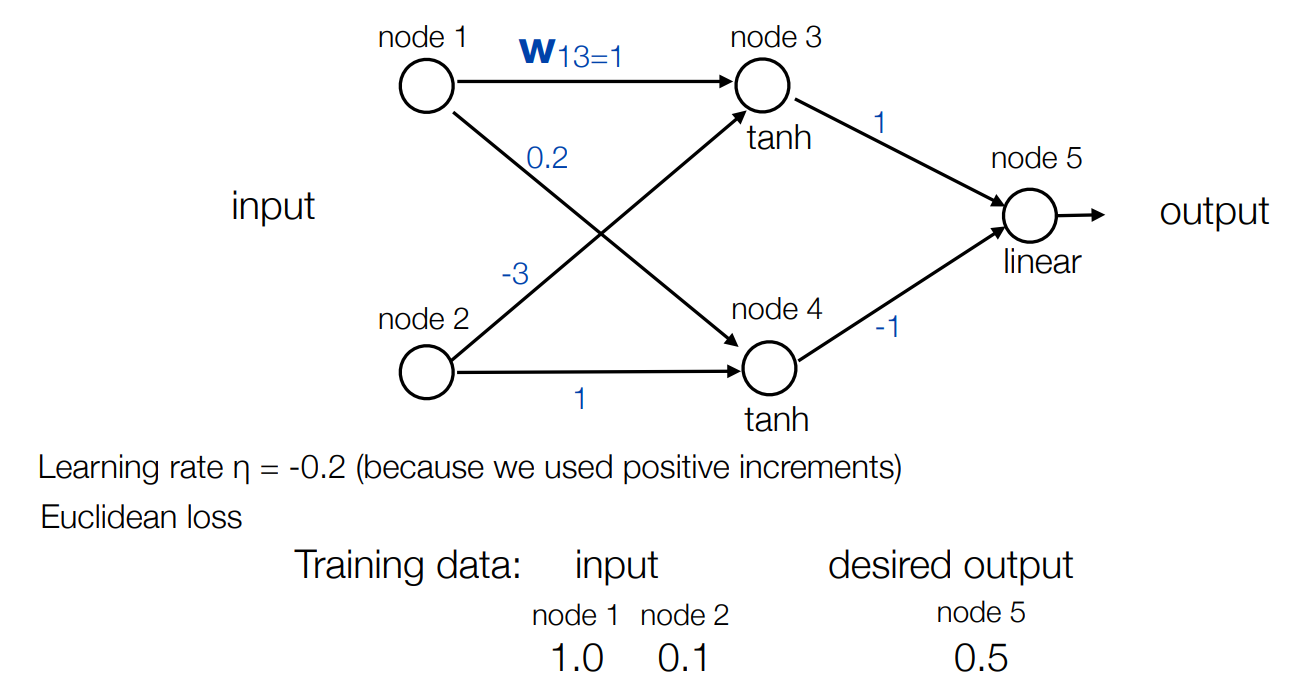

## setting down stuff

In [1]:
# ill use numpy here to simplify matrix calculation 
# (lets assume that matrix calculation is trivial)

import numpy as np

In [2]:
# this is the input (we'll always use column arrays here)
x0 = np.array([[+1.000], 
               [+0.100]])

# just to check array shape and output
print(x0.shape)
print(x0)

(2, 1)
[[1. ]
 [0.1]]


In [3]:
# this is the output
y = np.array([[+0.500]])

print(y.shape)
print(y)

(1, 1)
[[0.5]]


In [4]:
# lets define W0 as the weights matrix of the link between the first layer and second layer of nodes
W0 = np.array([[+1.000, -3.000],
               [+0.200, +1.000]])

print(W0.shape)
print(W0)

(2, 2)
[[ 1.  -3. ]
 [ 0.2  1. ]]


In [5]:
# likewise with W1, as the weights of the link between the second layer and third layer
W1 = np.array([[+1.000, -1.000]])

print(W1.shape)
print(W1)

(1, 2)
[[ 1. -1.]]


## forward pass

In [1062]:
# x1 is the second layer of nodes (pre-activation)
x1 = W0 @ x0

print(x1)

[[0.76932572]
 [0.19831813]]


In [1063]:
# x2 is the post-activation second layer of nodes
x2 = np.tanh(x1)

print(x2)

[[0.6465372 ]
 [0.19575844]]


In [1064]:
# x3 is the third layer of node
x3 = W1 @ x2

print(x3)

[[0.5]]


In [1065]:
# here we use the L2 (euclidean) loss it its matrix form
L = +0.500 * ((x3 - y).T @ (x3 - y))

print(L)

[[0.]]


## backward pass

### finding derivatives against node layers (x1/x2/x3)

In [1066]:
# the first order derivative of the loss value against x3 is pre-calculated on paper: 
# found as x3 - y
dL_dx3 = x3 - y

print(dL_dx3)

[[0.]]


In [1067]:
# we now find the first order derivative of the loss value against x2
dL_dx2 = dL_dx3 @ W1

print(dL_dx2)

[[0. 0.]]


In [1068]:
# lets now find the first order derivative of the loss value against x1,
# f' of f = tanh(x) is 1 - tanh^2(x) (we assume this as trivial)

# we convert to a diagonal matrix to enforce point-wise calculation
dx2_dx1 = np.diag((1 - np.tanh(x1) ** 2).flatten())
print(dx2_dx1)
print()

# then finally we calculate ∂L/∂x1
dL_dx1 = dL_dx2 @ dx2_dx1
print(dL_dx1)

[[0.58198965 0.        ]
 [0.         0.96167863]]

[[0. 0.]]


### finding derivatives against weights (W0, W1)

In [1069]:
# lets start with finding ∂L/∂W1,
# the resulting matrix tells us the slope of the W1 parameters in loss space
dL_dW1 = x2 @ dL_dx3
print(dL_dW1)

[[0.]
 [0.]]


In [1070]:
# now lets find ∂L/∂W1
# now this resulting matrix tells us the slope of the W0 parameters in loss space
dL_dW0 = x0 @ dL_dx1
print(dL_dW0)

[[0. 0.]
 [0. 0.]]


In [1071]:
# now since we know the slopes, we can tune the parameters downwards in loss space!
# lets start with changing W1
print(W1)
W1 = W1 + (-0.200 * dL_dW1).T
print(W1)

[[ 1.06774885 -0.97231746]]
[[ 1.06774885 -0.97231746]]


In [1072]:
# we'll do the same thing with W0
print(W0)
W0 = W0 + (-0.200 * dL_dW0).T
print(W1)

[[ 1.06863933 -2.99313607]
 [ 0.09932488  0.98993249]]
[[ 1.06774885 -0.97231746]]
